<a href="https://colab.research.google.com/github/shivanshi-09/IML_Midterm/blob/main/FNNDiabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from itertools import product as iterproduct
dataset = pd.read_csv("https://raw.githubusercontent.com/shivanshi-09/IML_Midterm/main/nhanes_diabetes_clean.csv")

In [3]:
drop_cols = ["SEQN", "LBXGH", "diabetes_label", "diabetes_binary"]
X = dataset.drop(columns = drop_cols)
y = dataset["diabetes_label"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [4]:
tier1_cols =[
    "RIDAGEYR", "RIAGENDR", "RIDRETH3", # demographics
    "BMXBMI", "BMXWAIST", # anthropometric
    "BPXSY_mean", "BPXDI_mean" # blood pressure
    ]
tier2_cols = tier1_cols +[
    "LBXTC", "LBXTR", # lipids
    "LBXSCR", # creatinine
    "LBXSATSI", "LBXSASSI", # liver enzymes (ALT, AST)
    "LBXSUA" # uric acid
]
tier3_cols = tier2_cols + [
    "LBXSTP", "LBXSAL", "LBXSCA", # total protein, albumin, calcium
    "LBXSPH", "LBXSNASI", "LBXSKSI", # phosphorus, sodium, potassium
    "LBXSGB", "LBXSBU", "LBXSC3SI"# globulin, BUN, bicarbonate
]
tiers = {
    "Tier 1 (Demographic + Vitals)": tier1_cols,
    "Tier 2 (Liver Measurements)": tier2_cols,
    "Tier 3 (Full Panel)": tier3_cols
}

In [5]:
from imblearn.over_sampling import SMOTE
def one_hot (y, n_classes):
  out = np.zeros((len(y), n_classes))
  out[np.arange(len(y)), y.astype(int)] = 1
  return out
smote = SMOTE(random_state=42)
def relu(z):
  return np.maximum(0, z)

def relu_grad(z):
  return (z > 0).astype(int)

def softmax(z):
  z = z- np.max(z, axis = 1, keepdims = True)
  exp = np.exp(z)
  return exp / np.sum(exp, axis = 1, keepdims = True)

def cross_entropy(y_true, y_pred):
  return -np.sum(y_true * np.log(y_pred + 1e-9))/y_true.shape[0]

In [6]:
def init_weights(layer_sizes, seed=42):
    np.random.seed(seed)
    weights, biases = [], []
    for i in range(len(layer_sizes) - 1):
        W = np.random.randn(layer_sizes[i], layer_sizes[i+1]) * np.sqrt(2.0 / layer_sizes[i])
        b = np.zeros(layer_sizes[i+1])
        weights.append(W)
        biases.append(b)
    return weights, biases

def forward_fnn(X, weights, biases, dropout_rate=0.0, training=True):
    activations = [X]
    current = X
    for i in range(len(weights) - 1):
        z = current @ weights[i] + biases[i]
        a = relu(z)
        if training and dropout_rate > 0:
            mask = (np.random.rand(*a.shape) > dropout_rate) / (1 - dropout_rate)
            a = a * mask
        activations.append(a)
        current = a
    z_out = current @ weights[-1] + biases[-1]
    out = softmax(z_out)
    activations.append(out)
    return activations

def backward_fnn(X, Y, activations, weights, biases, alpha, class_weights=None):
    n = X.shape[0]
    grad_weights = [None] * len(weights)
    grad_biases  = [None] * len(biases)
    delta = activations[-1] - Y
    if class_weights is not None:
        sample_weights = np.sum(Y * class_weights, axis=1, keepdims=True)
        delta = delta * sample_weights
    for i in reversed(range(len(weights))):
        grad_weights[i] = (activations[i].T @ delta) / n
        grad_biases[i]  = np.mean(delta, axis=0)
        if i > 0:
            delta = (delta @ weights[i].T) * (activations[i] > 0)
    for i in range(len(weights)):
        weights[i] -= alpha * grad_weights[i]
        biases[i]  -= alpha * grad_biases[i]
    return weights, biases

def cross_entropy_weighted(y_true, y_pred, class_weights):
    weights = np.sum(y_true * class_weights, axis=1)
    loss = -np.sum(weights * np.sum(y_true * np.log(y_pred + 1e-9), axis=1)) / y_true.shape[0]
    return loss

def train_fnn(X_train, Y_train, X_test, Y_test, layer_sizes, alpha=0.01, dropout=0.0, epochs=500, batch_size=None, class_weights=None):
    weights, biases = init_weights(layer_sizes)
    train_losses_history, test_losses_history = [], []
    n = X_train.shape[0]
    if batch_size is None:
        batch_size = n

    for epoch in range(epochs):
        idx = np.random.permutation(n)
        X_shuf, Y_shuf = X_train[idx], Y_train[idx]
        for start in range(0, n, batch_size):
            Xb = X_shuf[start:start+batch_size]
            Yb = Y_shuf[start:start+batch_size]
            activations = forward_fnn(Xb, weights, biases, dropout, training=True)
            weights, biases = backward_fnn(Xb, Yb, activations, weights, biases, alpha, class_weights)

        train_acts = forward_fnn(X_train, weights, biases, training=False)
        test_acts  = forward_fnn(X_test,  weights, biases, training=False)

        if class_weights is not None:
            train_loss = cross_entropy_weighted(Y_train, train_acts[-1], class_weights)
            test_loss  = cross_entropy_weighted(Y_test,  test_acts[-1],  class_weights)
        else:
            train_loss = cross_entropy(Y_train, train_acts[-1])
            test_loss  = cross_entropy(Y_test,  test_acts[-1])

        train_losses_history.append(train_loss)
        test_losses_history.append(test_loss)

        if epoch % 50 == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.4f}  Val Loss: {test_loss:.4f}")

    return weights, biases, train_losses_history, test_losses_history

def predict_fnn(X, weights, biases):
    activations = forward_fnn(X, weights, biases, dropout_rate=0.0, training=False)
    y_probs = activations[-1]
    y_pred  = np.argmax(y_probs, axis=1)
    return y_pred, y_probs

In [7]:
def confusion_matrix_counts (y_true, y_pred):
  TP = np.sum((y_true == 1) & (y_pred ==1))
  FP = np.sum((y_true == 0) & (y_pred ==1))
  TN = np.sum((y_true == 0) & (y_pred ==0))
  FN = np.sum((y_true == 1) & (y_pred ==0))
  return TP, FP, TN, FN

def f1_classwise(y_true, y_pred, n_classes):
  results ={}
  for c in range(n_classes):
    y_true_bin = (y_true == c).astype(int)
    y_pred_bin = (y_pred == c).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true_bin, y_pred_bin)
    precision = TP / (TP + FP+ 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall)
    results [c] = {"f1": f1, "precision": precision, "recall": recall}
  return results


In [8]:
def auroc(y_true, y_prob):
  thresholds = np.linspace(0,1, 1000)
  tprs, fprs = [], []
  for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)
    TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
    tprs.append(TP/(TP+FN +1e-9))
    fprs.append(FP/(FP+TN +1e-9))
  fprs, tprs = zip(*sorted(zip(fprs, tprs)))
  fprs, tprs = np.array(fprs), np.array(tprs)
  auroc = np.trapezoid(tprs, fprs)
  return auroc, fprs, tprs

In [9]:
def auprc(y_true, y_prob):
    thresholds = np.linspace(0, 1, 1000)
    precisions, recalls = [], []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        TP, FP, TN, FN = confusion_matrix_counts(y_true, y_pred)
        precisions.append(TP / (TP + FP + 1e-9))
        recalls.append(TP / (TP + FN + 1e-9))

    recalls = np.array(recalls)
    precisions = np.array(precisions)

    sorted_idx = np.argsort(recalls)
    recalls = recalls[sorted_idx]
    precisions = precisions[sorted_idx]

    auprc_val = np.trapezoid(precisions, recalls)
    return auprc_val, recalls, precisions


 ------- Tier 1 (Demographic + Vitals) -----------
Epoch    0 | Train Loss: 0.9721  Val Loss: 1.0022
Epoch   50 | Train Loss: 0.8265  Val Loss: 0.8918
Epoch  100 | Train Loss: 0.7900  Val Loss: 0.9390
Epoch  150 | Train Loss: 0.7738  Val Loss: 0.9741
Epoch  200 | Train Loss: 0.7029  Val Loss: 1.0017
Epoch  250 | Train Loss: 0.6544  Val Loss: 1.0420
Epoch    0 | Train Loss: 1.0042  Val Loss: 1.0023
Epoch   50 | Train Loss: 0.8620  Val Loss: 0.8955
Epoch  100 | Train Loss: 0.8457  Val Loss: 0.8935
Epoch  150 | Train Loss: 0.8319  Val Loss: 0.8944
Epoch  200 | Train Loss: 0.8185  Val Loss: 0.9016
Epoch  250 | Train Loss: 0.8082  Val Loss: 0.9100
Epoch    0 | Train Loss: 1.5538  Val Loss: 1.5245
Epoch   50 | Train Loss: 0.9800  Val Loss: 0.9824
Epoch  100 | Train Loss: 0.9417  Val Loss: 0.9462
Epoch  150 | Train Loss: 0.9252  Val Loss: 0.9306
Epoch  200 | Train Loss: 0.9156  Val Loss: 0.9216
Epoch  250 | Train Loss: 0.9090  Val Loss: 0.9157
Epoch    0 | Train Loss: 0.9313  Val Loss: 0.916

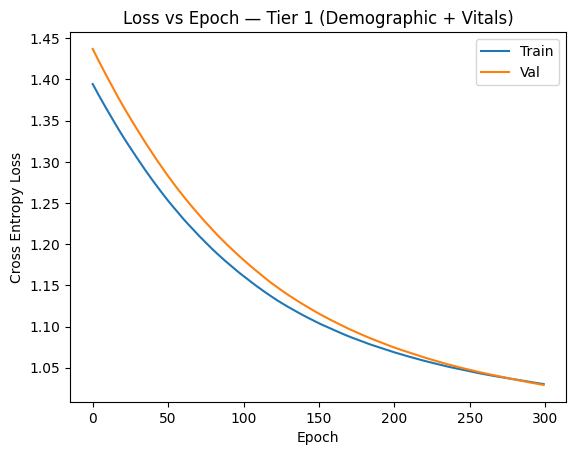

Class 0 (Healthy     ) | F1: 0.6124  AUROC: 0.7439  AUPRC: 0.8208
Class 1 (Prediabetic ) | F1: 0.2865  AUROC: 0.5268  AUPRC: 0.2856
Class 2 (Diabetic    ) | F1: 0.2677  AUROC: 0.7096  AUPRC: 0.2083

 ------- Tier 2 (Liver Measurements) -----------
Epoch    0 | Train Loss: 0.9439  Val Loss: 0.9651
Epoch   50 | Train Loss: 0.7199  Val Loss: 0.9044
Epoch  100 | Train Loss: 0.7951  Val Loss: 1.1995
Epoch  150 | Train Loss: 0.6124  Val Loss: 1.1818
Epoch  200 | Train Loss: 0.3970  Val Loss: 1.2958
Epoch  250 | Train Loss: 0.4206  Val Loss: 1.6701
Epoch    0 | Train Loss: 1.0489  Val Loss: 1.0527
Epoch   50 | Train Loss: 0.8140  Val Loss: 0.8784
Epoch  100 | Train Loss: 0.7713  Val Loss: 0.8827
Epoch  150 | Train Loss: 0.7355  Val Loss: 0.8943
Epoch  200 | Train Loss: 0.7007  Val Loss: 0.9151
Epoch  250 | Train Loss: 0.6672  Val Loss: 0.9287
Epoch    0 | Train Loss: 1.3178  Val Loss: 1.2914
Epoch   50 | Train Loss: 1.0160  Val Loss: 1.0197
Epoch  100 | Train Loss: 0.9565  Val Loss: 0.9637
Ep

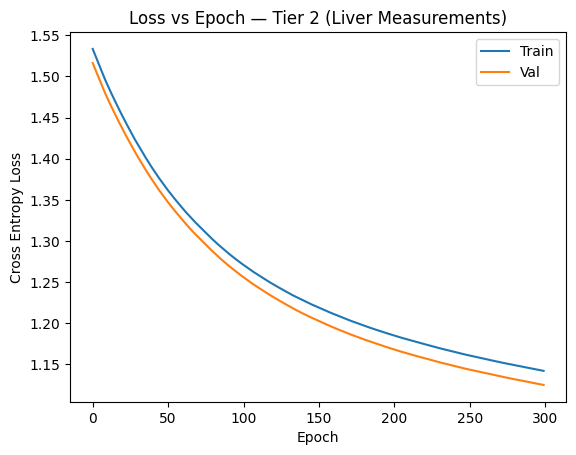

Class 0 (Healthy     ) | F1: 0.5554  AUROC: 0.6464  AUPRC: 0.7703
Class 1 (Prediabetic ) | F1: 0.3057  AUROC: 0.5932  AUPRC: 0.3270
Class 2 (Diabetic    ) | F1: 0.1964  AUROC: 0.5518  AUPRC: 0.1275

 ------- Tier 3 (Full Panel) -----------
Epoch    0 | Train Loss: 0.9745  Val Loss: 1.0066
Epoch   50 | Train Loss: 0.5924  Val Loss: 0.9348
Epoch  100 | Train Loss: 0.4243  Val Loss: 1.1290
Epoch  150 | Train Loss: 0.2565  Val Loss: 1.4612
Epoch  200 | Train Loss: 0.1633  Val Loss: 1.7911
Epoch  250 | Train Loss: 0.0954  Val Loss: 2.0325
Epoch    0 | Train Loss: 1.1192  Val Loss: 1.1427
Epoch   50 | Train Loss: 0.7840  Val Loss: 0.8825
Epoch  100 | Train Loss: 0.7105  Val Loss: 0.8918
Epoch  150 | Train Loss: 0.6466  Val Loss: 0.9163
Epoch  200 | Train Loss: 0.5811  Val Loss: 0.9489
Epoch  250 | Train Loss: 0.5284  Val Loss: 0.9896
Epoch    0 | Train Loss: 1.4213  Val Loss: 1.4106
Epoch   50 | Train Loss: 1.0838  Val Loss: 1.1100
Epoch  100 | Train Loss: 1.0091  Val Loss: 1.0339
Epoch  150

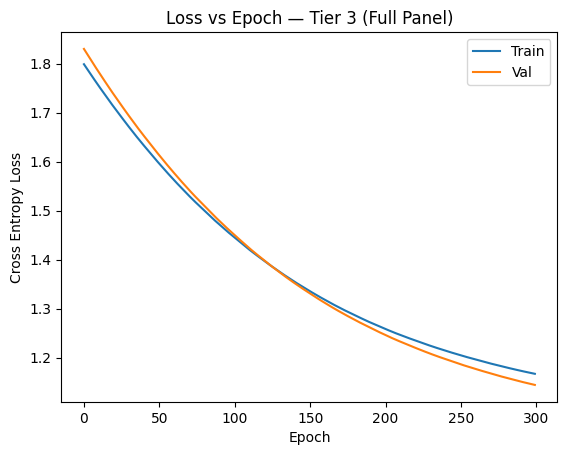

Class 0 (Healthy     ) | F1: 0.4882  AUROC: 0.6571  AUPRC: 0.7435
Class 1 (Prediabetic ) | F1: 0.3921  AUROC: 0.6433  AUPRC: 0.3527
Class 2 (Diabetic    ) | F1: 0.1899  AUROC: 0.5542  AUPRC: 0.1688


--------average across tiers--------
Class             Avg F1  Avg AUROC  Avg AUPRC
---------------------------------------------
Healthy           0.5520     0.6824     0.7782
Prediabetic       0.3281     0.5878     0.3218
Diabetic          0.2180     0.6052     0.1682


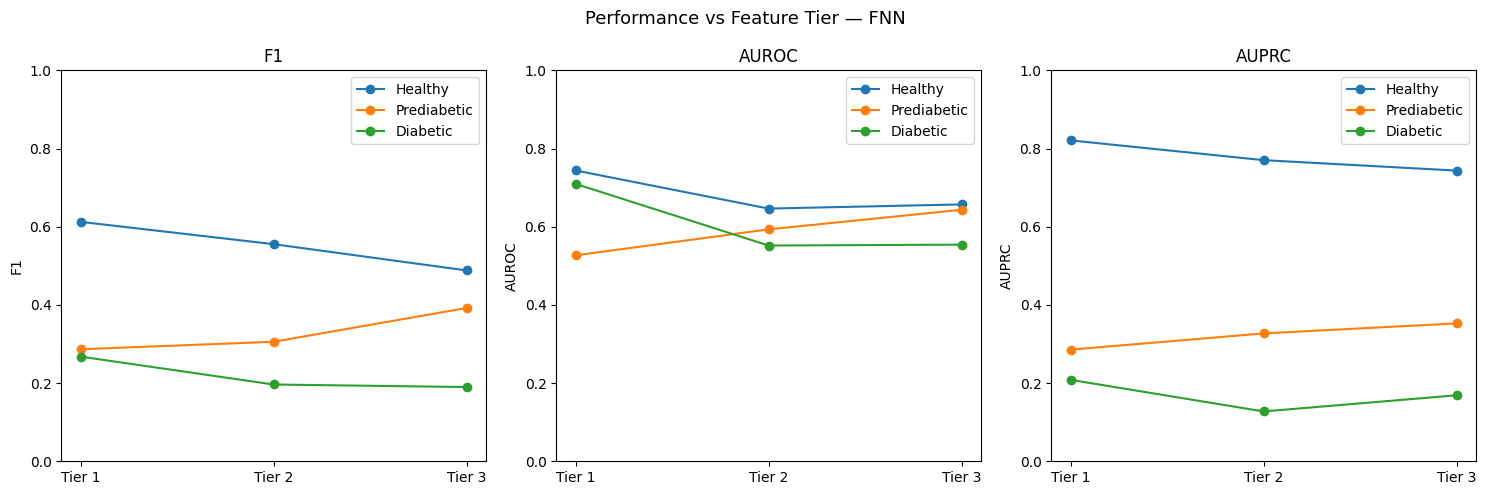

In [13]:

alphas = [0.01, 0.001]
dropouts = [0.0, 0.3]
architectures = [
    [128, 64],
    [256, 128, 64],
    [64, 32],
]
batch_sizes = [32, 128, len(x_train)]
n_classes  = 3
class_names = ["Healthy", "Prediabetic", "Diabetic"]
tier_results = {}
all_logs = []

for tier_name, cols in tiers.items():
    print(f"\n ------- {tier_name} -----------")
    scaler = StandardScaler()
    X_train_tier = scaler.fit_transform(x_train[cols])
    X_test_tier  = scaler.transform(x_test[cols])
    Y_train_tier = one_hot(y_train.values, n_classes)
    Y_test_tier  = one_hot(y_test.values,  n_classes)

    counts = np.bincount(y_train.values.astype(int))
    class_weights = len(y_train) / (n_classes * counts)

    best_test_loss = float('inf')
    best_params = None
    for alpha, d, arch, bs in iterproduct(alphas, dropouts, architectures, batch_sizes):
      layer_sizes = [X_train_tier.shape[1]]+ arch +[n_classes]
      W, b, train_losses, test_losses = train_fnn(
      X_train_tier, Y_train_tier,
      X_test_tier,  Y_test_tier,
      layer_sizes,
      alpha= alpha,
      dropout=d,
      epochs=300,
      batch_size=bs,
      class_weights=class_weights
  )
      final_train_loss = train_losses[-1]
      final_test_loss  = test_losses[-1]

      all_logs.append({
          "tier": tier_name,
          "alpha": alpha,
          "dropout": d,
          "arch": arch,
          "batch_size": bs,
          "train_loss": final_train_loss,
          "test_loss": final_test_loss
      })
      if final_test_loss < best_test_loss:
          best_val_loss = test_losses[-1]
          best_params   = {"alpha": alpha, "dropout": d, "arch": arch, "batch_size": bs}
          best_train_losses, best_test_losses = train_losses, test_losses
          best_W, best_b = W, b

    print(f"\nBest params: lr={best_params['alpha']}  dropout={best_params['dropout']}  "
          f"arch={best_params['arch']}  batch_size={best_params['batch_size']}")

    plt.plot(best_train_losses, label="Train")
    plt.plot(best_test_losses,  label="Val")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Cross Entropy Loss")
    plt.title(f"Loss vs Epoch — {tier_name}"); plt.show()

    y_pred, y_probs = predict_fnn(X_test_tier, best_W, best_b)
    y_true = y_test.values
    f1_scores = f1_classwise(y_true, y_pred, n_classes)

    tier_results[tier_name] = {"f1": {}, "auroc": {}, "auprc": {}}
    for c in range(n_classes):
        y_true_bin = (y_true == c).astype(int)
        auroc_val, _, _ = auroc(y_true_bin, y_probs[:, c])
        auprc_val, _, _ = auprc(y_true_bin,  y_probs[:, c])
        f1_val = f1_scores[c]["f1"]
        tier_results[tier_name]["f1"][c]    = f1_val
        tier_results[tier_name]["auroc"][c] = auroc_val
        tier_results[tier_name]["auprc"][c] = auprc_val
        print(f"Class {c} ({class_names[c]:12s}) | F1: {f1_val:.4f}  AUROC: {auroc_val:.4f}  AUPRC: {auprc_val:.4f}")

print("\n\n--------average across tiers--------")
print(f"{'Class':<15} {'Avg F1':>8} {'Avg AUROC':>10} {'Avg AUPRC':>10}")
print("-" * 45)
for c, cname in enumerate(class_names):
    avg_f1    = np.mean([tier_results[t]["f1"][c]    for t in tier_results])
    avg_auroc = np.mean([tier_results[t]["auroc"][c] for t in tier_results])
    avg_auprc = np.mean([tier_results[t]["auprc"][c] for t in tier_results])
    print(f"{cname:<15} {avg_f1:>8.4f} {avg_auroc:>10.4f} {avg_auprc:>10.4f}")

tier_names = list(tier_results.keys())
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, label in zip(axes, ["f1", "auroc", "auprc"], ["F1", "AUROC", "AUPRC"]):
    for c, cname in enumerate(class_names):
        scores = [tier_results[t][metric][c] for t in tier_names]
        ax.plot(["Tier 1", "Tier 2", "Tier 3"], scores, marker="o", label=cname)
    ax.set_title(label); ax.set_ylabel(label)
    ax.legend(); ax.set_ylim(0, 1)
plt.suptitle("Performance vs Feature Tier — FNN", fontsize=13)
plt.tight_layout(); plt.show()


 ------ Tier 1 (Demographic + Vitals)-------
Epoch    0 | Train Loss: 0.8007  Val Loss: 0.7762
Epoch   50 | Train Loss: 0.7546  Val Loss: 0.7426
Epoch  100 | Train Loss: 0.7461  Val Loss: 0.7396
Epoch  150 | Train Loss: 0.7447  Val Loss: 0.7390
Epoch  200 | Train Loss: 0.7428  Val Loss: 0.7403
Epoch  250 | Train Loss: 0.7415  Val Loss: 0.7376


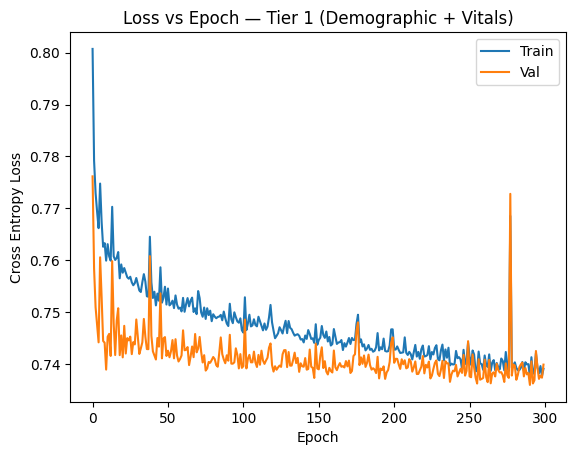

Class 0 (Healthy     ) | F1: 0.7963  AUROC: 0.8154  AUPRC: 0.8775
Class 1 (Prediabetic ) | F1: 0.3059  AUROC: 0.7215  AUPRC: 0.4218
Class 2 (Diabetic    ) | F1: 0.1375  AUROC: 0.8017  AUPRC: 0.2925

 ------ Tier 2 (Liver Measurements)-------
Epoch    0 | Train Loss: 0.8192  Val Loss: 0.7988
Epoch   50 | Train Loss: 0.7379  Val Loss: 0.7252
Epoch  100 | Train Loss: 0.7294  Val Loss: 0.7248
Epoch  150 | Train Loss: 0.7239  Val Loss: 0.7255
Epoch  200 | Train Loss: 0.7154  Val Loss: 0.7214
Epoch  250 | Train Loss: 0.7094  Val Loss: 0.7195


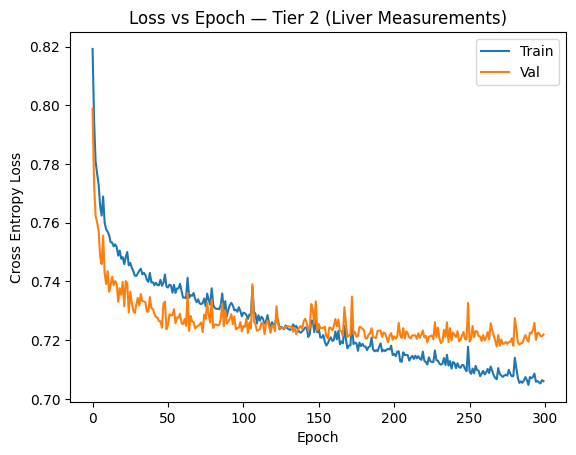

Class 0 (Healthy     ) | F1: 0.8038  AUROC: 0.8227  AUPRC: 0.8826
Class 1 (Prediabetic ) | F1: 0.3643  AUROC: 0.7256  AUPRC: 0.4171
Class 2 (Diabetic    ) | F1: 0.1928  AUROC: 0.8266  AUPRC: 0.3545

 ------ Tier 3 (Full Panel)-------
Epoch    0 | Train Loss: 0.8644  Val Loss: 0.8588
Epoch   50 | Train Loss: 0.7303  Val Loss: 0.7256
Epoch  100 | Train Loss: 0.7129  Val Loss: 0.7197
Epoch  150 | Train Loss: 0.6995  Val Loss: 0.7135
Epoch  200 | Train Loss: 0.6898  Val Loss: 0.7115
Epoch  250 | Train Loss: 0.6807  Val Loss: 0.7112


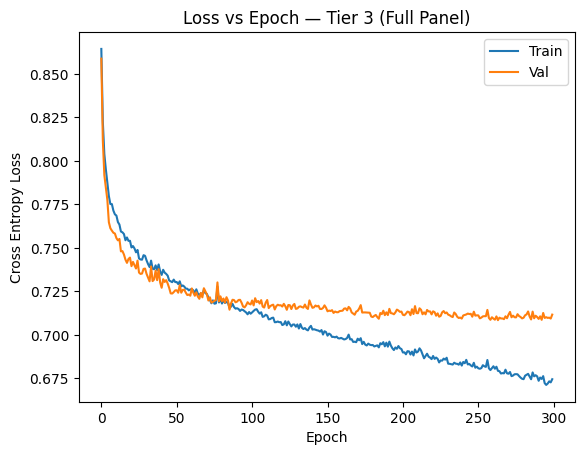

Class 0 (Healthy     ) | F1: 0.8051  AUROC: 0.8259  AUPRC: 0.8841
Class 1 (Prediabetic ) | F1: 0.3899  AUROC: 0.7313  AUPRC: 0.4393
Class 2 (Diabetic    ) | F1: 0.1988  AUROC: 0.8392  AUPRC: 0.4027


--------average across tiers--------
Class             Avg F1  Avg AUROC  Avg AUPRC
---------------------------------------------
Healthy           0.8017     0.8214     0.8814
Prediabetic       0.3534     0.7262     0.4261
Diabetic          0.1764     0.8225     0.3499


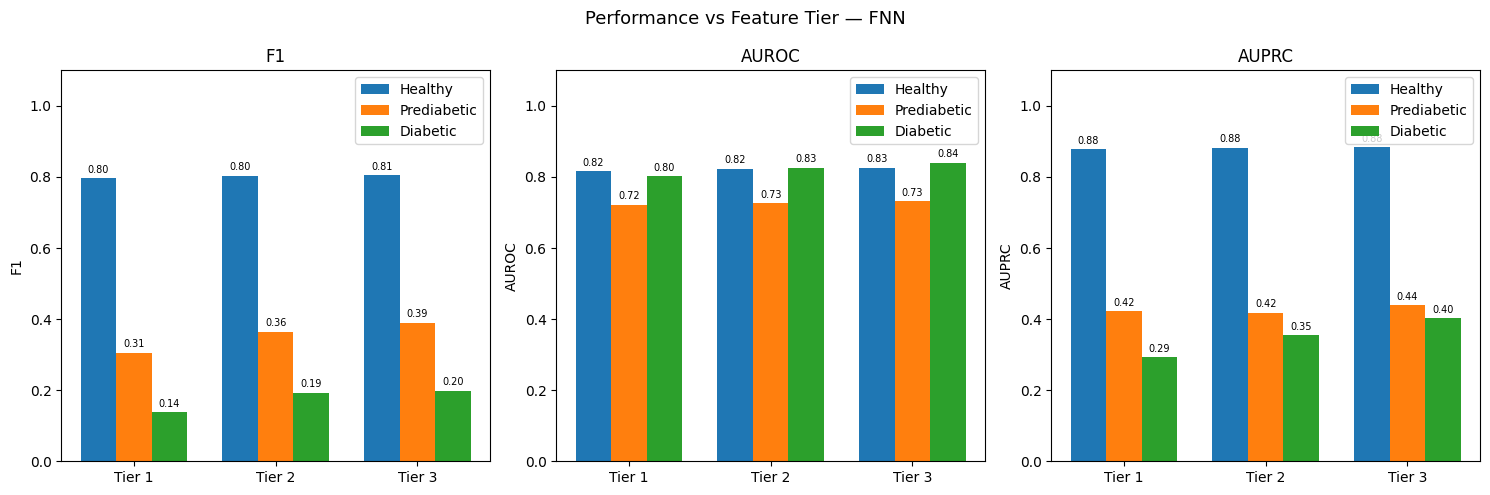

In [11]:
n_classes = 3
class_names = ["Healthy", "Prediabetic", "Diabetic"]
tier_results = {}
opt_param = {"alpha": 0.01, "dropout":0.3, "arch": [128, 64], "batch_size": 32}

for tier_name, cols in tiers.items():
    print(f"\n ------ {tier_name}-------")
    scalar = StandardScaler()
    X_train_tier = scalar.fit_transform(x_train[cols])
    X_test_tier  = scalar.transform(x_test[cols])
    Y_train_tier = one_hot(y_train.values, n_classes)
    Y_test_tier  = one_hot(y_test.values, n_classes)
    n_feat = X_train_tier.shape[1]
    layer_sizes = [n_feat] + opt_param["arch"] + [n_classes]

    W, b, train_losses, test_losses = train_fnn(
        X_train_tier, Y_train_tier,
        X_test_tier,  Y_test_tier,
        layer_sizes, alpha=opt_param["alpha"], dropout=opt_param["dropout"],
        epochs=300, batch_size=opt_param["batch_size"]
    )

    plt.plot(train_losses, label="Train")
    plt.plot(test_losses,  label="Val")
    plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Cross Entropy Loss")
    plt.title(f"Loss vs Epoch — {tier_name}"); plt.show()

    y_pred, y_probs = predict_fnn(X_test_tier, W, b)
    y_true = y_test.values
    f1_scores = f1_classwise(y_true, y_pred, n_classes)

    tier_results[tier_name] = {"f1": {}, "auroc": {}, "auprc": {}}
    for c in range(n_classes):
        y_true_bin = (y_true == c).astype(int)
        auroc_val, _, _ = auroc(y_true_bin, y_probs[:, c])
        auprc_val, _, _ = auprc(y_true_bin, y_probs[:, c])
        f1_val = f1_scores[c]["f1"]
        tier_results[tier_name]["f1"][c]    = f1_val
        tier_results[tier_name]["auroc"][c] = auroc_val
        tier_results[tier_name]["auprc"][c] = auprc_val
        print(f"Class {c} ({class_names[c]:12s}) | F1: {f1_val:.4f}  AUROC: {auroc_val:.4f}  AUPRC: {auprc_val:.4f}")

print("\n\n--------average across tiers--------")
print(f"{'Class':<15} {'Avg F1':>8} {'Avg AUROC':>10} {'Avg AUPRC':>10}")
print("-" * 45)
for c, cname in enumerate(class_names):
    avg_f1    = np.mean([tier_results[t]["f1"][c]    for t in tier_results])
    avg_auroc = np.mean([tier_results[t]["auroc"][c] for t in tier_results])
    avg_auprc = np.mean([tier_results[t]["auprc"][c] for t in tier_results])
    print(f"{cname:<15} {avg_f1:>8.4f} {avg_auroc:>10.4f} {avg_auprc:>10.4f}")

tier_names  = list(tier_results.keys())
tier_labels = ["Tier 1", "Tier 2", "Tier 3"]
x     = np.arange(len(tier_labels))
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, label in zip(axes, ["f1", "auroc", "auprc"], ["F1", "AUROC", "AUPRC"]):
    for i, (cname, offset) in enumerate(zip(class_names, [-width, 0, width])):
        scores = [tier_results[t][metric][i] for t in tier_names]
        bars = ax.bar(x + offset, scores, width=width, label=cname)
        for bar, score in zip(bars, scores):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f"{score:.2f}",
                ha="center", va="bottom", fontsize=7
            )
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.set_xticks(x)
    ax.set_xticklabels(tier_labels)
    ax.legend()
    ax.set_ylim(0, 1.1)

plt.suptitle("Performance vs Feature Tier — FNN", fontsize=13)
plt.tight_layout()
plt.show()